# Final Experiments Part 2: Learning Curves
**CS 593 NLP Final Project — Purdue University, Spring 2026**

Authors: Varun Chundru, Debasmita Biswas

This notebook trains DeBERTa-v3-base from scratch on four training set sizes
(10%, 25%, 50%, 100% of the HaluEval training set) to characterize the
data-efficiency of the hallucination detection model.

**Research question:** How much training data is needed to reach the
peak F1 observed in Update 1 (F1=0.91)? Is the model data-hungry, or would
substantially less data suffice?

**Expected runtime:** ~3–4 hours on T4x2 (four fine-tuning runs).

**Environment:** Kaggle Notebook with GPU (T4x2)

## 1. Setup and Imports

In [1]:
import os
import time
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset, concatenate_datasets, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")

Device: cuda
GPU: Tesla T4
GPU count: 2


## 2. Load HaluEval — SAME splits as notebooks 01, 02, 03

In [2]:
print("Loading HaluEval...")
dataset_qa = load_dataset("pminervini/HaluEval", "qa_samples")
dataset_dialogue = load_dataset("pminervini/HaluEval", "dialogue_samples")
dataset_summarization = load_dataset("pminervini/HaluEval", "summarization_samples")

Loading HaluEval...


README.md: 0.00B [00:00, ?B/s]

qa_samples/data-00000-of-00001.parquet:   0%|          | 0.00/3.43M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

dialogue_samples/data-00000-of-00001.par(…):   0%|          | 0.00/2.83M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

summarization_samples/data-00000-of-0000(…):   0%|          | 0.00/25.5M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [3]:
def preprocess_qa_samples(examples):
    processed = {'text': [], 'label': [], 'task': []}
    for i in range(len(examples['knowledge'])):
        knowledge = examples['knowledge'][i]
        question = examples['question'][i]
        answer = examples['answer'][i]
        hallucination = examples['hallucination'][i]
        context = f"Question: {question}\nKnowledge: {knowledge}"
        text = f"{context}\n\nAnswer: {answer}"
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('qa')
    return processed

def preprocess_dialogue_samples(examples):
    processed = {'text': [], 'label': [], 'task': []}
    for i in range(len(examples['dialogue_history'])):
        history = examples['dialogue_history'][i]
        knowledge = examples['knowledge'][i] if 'knowledge' in examples else ""
        response = examples['response'][i]
        hallucination = examples['hallucination'][i]
        context = f"Dialogue: {history}\nKnowledge: {knowledge}"
        text = f"{context}\n\nResponse: {response}"
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('dialogue')
    return processed

def preprocess_summarization_samples(examples):
    processed = {'text': [], 'label': [], 'task': []}
    for i in range(len(examples['document'])):
        document = examples['document'][i]
        summary = examples['summary'][i]
        hallucination = examples['hallucination'][i]
        text = f"Document: {document[:1500]}\n\nSummary: {summary}"
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('summarization')
    return processed

In [4]:
qa_processed = dataset_qa['data'].map(preprocess_qa_samples, batched=True, remove_columns=dataset_qa['data'].column_names)
dialogue_processed = dataset_dialogue['data'].map(preprocess_dialogue_samples, batched=True, remove_columns=dataset_dialogue['data'].column_names)
summarization_processed = dataset_summarization['data'].map(preprocess_summarization_samples, batched=True, remove_columns=dataset_summarization['data'].column_names)

combined = concatenate_datasets([qa_processed, dialogue_processed, summarization_processed])
combined = combined.shuffle(seed=42)
train_test = combined.train_test_split(test_size=0.3, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

full_splits = DatasetDict({
    'train': train_test['train'],
    'validation': val_test['train'],
    'test': val_test['test']
})

print(f"Full splits — Train: {len(full_splits['train'])}  Val: {len(full_splits['validation'])}  Test: {len(full_splits['test'])}")

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Full splits — Train: 21000  Val: 4500  Test: 4500


## 3. Tokenization

In [5]:
MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True, max_length=512, padding=False)


# Tokenize full dataset once (we'll sample from it for each size)
print("Tokenizing full dataset (one-time cost)...")
tokenized_full = full_splits.map(
    tokenize_fn, batched=True,
    remove_columns=[c for c in full_splits['train'].column_names if c not in ['label']]
)
tokenized_full = tokenized_full.rename_column('label', 'labels')
tokenized_full.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print(f"Train tokenized: {len(tokenized_full['train'])}")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenizing full dataset (one-time cost)...


Map:   0%|          | 0/21000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Train tokenized: 21000


In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    try:
        auroc = roc_auc_score(labels, probs)
    except ValueError:
        auroc = 0.0
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1, 'auroc': auroc}

## 4. Learning curve loop

For each fraction, sample a stratified subset and fine-tune DeBERTa-v3-base.

In [7]:
SIZES = [0.10, 0.25, 0.50, 1.00]
learning_curve_results = []

full_train = tokenized_full['train']
full_val = tokenized_full['validation']
full_test = tokenized_full['test']

# Stratify by label to preserve class balance
train_labels_full = np.array(full_splits['train']['label'])
pos_indices = np.where(train_labels_full == 1)[0]
neg_indices = np.where(train_labels_full == 0)[0]

print(f"Full train: {len(full_train)} ({len(pos_indices)} positive, {len(neg_indices)} negative)")

Full train: 21000 (10508 positive, 10492 negative)


In [9]:
for frac in SIZES:
    print(f"\n{'='*70}")
    print(f"Training with {int(frac*100)}% of data")
    print(f"{'='*70}")

    # Stratified sampling
    rng = np.random.RandomState(42)
    n_pos = int(len(pos_indices) * frac)
    n_neg = int(len(neg_indices) * frac)
    sampled_pos = rng.choice(pos_indices, n_pos, replace=False)
    sampled_neg = rng.choice(neg_indices, n_neg, replace=False)
    subset_indices = np.concatenate([sampled_pos, sampled_neg])
    rng.shuffle(subset_indices)
    subset_indices = subset_indices.tolist()

    train_subset = full_train.select(subset_indices)
    print(f"Subset size: {len(train_subset)} ({n_pos} pos, {n_neg} neg)")

    # Fresh model initialization
    print(f"Loading fresh DeBERTa-v3-base...")
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    )
    model = model.float()
    model = model.to(device)

    training_args = TrainingArguments(
        output_dir=f"./lc_model_{int(frac*100)}pct",
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=200,
        eval_strategy="no",
        save_strategy="no",
        fp16=False,  # fp32 — avoids NaN issue seen in Update 1
        report_to="none",
        seed=42,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_subset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    train_time = time.time() - start
    print(f"Training time: {train_time/60:.1f} min")

    # Evaluate on test set
    print(f"Evaluating on test set...")
    test_metrics = trainer.evaluate(full_test)
    print(f"Test metrics: {test_metrics}")

    learning_curve_results.append({
        'fraction': frac,
        'train_size': len(train_subset),
        'train_time_min': train_time / 60,
        'accuracy': test_metrics['eval_accuracy'],
        'precision': test_metrics['eval_precision'],
        'recall': test_metrics['eval_recall'],
        'f1': test_metrics['eval_f1'],
        'auroc': test_metrics['eval_auroc'],
    })

    # Clean up GPU memory before next iteration
    del model, trainer
    torch.cuda.empty_cache()


Training with 10% of data
Subset size: 2099 (1050 pos, 1049 neg)
Loading fresh DeBERTa-v3-base...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight        

Step,Training Loss
200,1.392361


Training time: 6.8 min
Evaluating on test set...


...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight        

Step,Training Loss
200,1.395518
400,1.390535
600,1.389397
800,1.386836
1000,1.390375
1200,1.388913
1400,1.384432
1600,1.388592
1800,1.386546
2000,1.384914


Training time: 69.5 min
Evaluating on test set...


Test metrics: {'eval_loss': 1.4764713048934937, 'eval_accuracy': 0.494, 'eval_precision': 0.494, 'eval_recall': 1.0, 'eval_f1': 0.6613119143239625, 'eval_auroc': 0.8717253309167878, 'eval_runtime': 105.9941, 'eval_samples_per_second': 42.455, 'eval_steps_per_second': 1.33, 'epoch': 3.0}


## 5. Results and plots

In [10]:
lc_df = pd.DataFrame(learning_curve_results)
print("\nLearning Curve Results:")
print(lc_df.to_string(index=False))

lc_df.to_csv("learning_curve_results.csv", index=False)
print("\nSaved: learning_curve_results.csv")


Learning Curve Results:
 fraction  train_size  train_time_min  accuracy  precision   recall       f1    auroc
     0.10        2099        6.835693  0.512889   0.503969 0.885290 0.642298 0.523617
     0.25        5250       17.440944  0.766889   0.710848 0.890238 0.790493 0.874248
     0.50       10500       34.727632  0.721333   0.650233 0.943320 0.769824 0.869597
     1.00       21000       69.478802  0.494000   0.494000 1.000000 0.661312 0.871725

Saved: learning_curve_results.csv


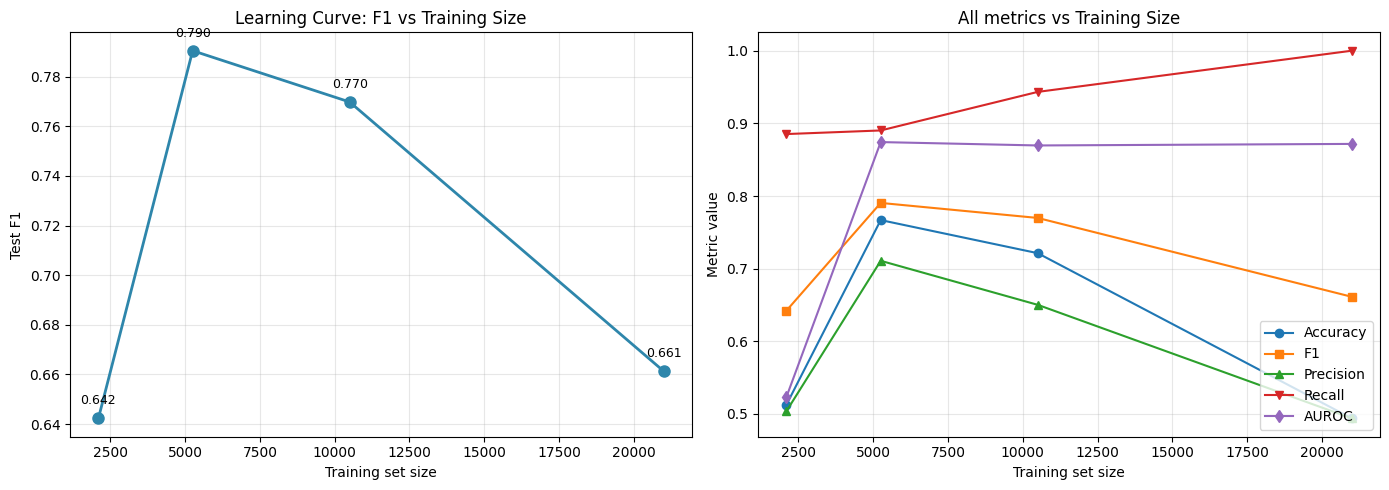

Saved: learning_curve.png


In [11]:
# Plot learning curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 vs training size
axes[0].plot(lc_df['train_size'], lc_df['f1'], 'o-', markersize=8, linewidth=2, color='#2E86AB')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('Test F1')
axes[0].set_title('Learning Curve: F1 vs Training Size')
axes[0].grid(True, alpha=0.3)
for _, row in lc_df.iterrows():
    axes[0].annotate(f"{row['f1']:.3f}",
                     (row['train_size'], row['f1']),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

# Plot 2: All metrics
axes[1].plot(lc_df['train_size'], lc_df['accuracy'], 'o-', label='Accuracy', markersize=6)
axes[1].plot(lc_df['train_size'], lc_df['f1'], 's-', label='F1', markersize=6)
axes[1].plot(lc_df['train_size'], lc_df['precision'], '^-', label='Precision', markersize=6)
axes[1].plot(lc_df['train_size'], lc_df['recall'], 'v-', label='Recall', markersize=6)
axes[1].plot(lc_df['train_size'], lc_df['auroc'], 'd-', label='AUROC', markersize=6)
axes[1].set_xlabel('Training set size')
axes[1].set_ylabel('Metric value')
axes[1].set_title('All metrics vs Training Size')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150)
plt.show()
print("Saved: learning_curve.png")

In [12]:
# Summary statistics
print(f"\n{'='*60}")
print(f"Learning Curve Analysis")
print(f"{'='*60}")

peak_f1 = lc_df['f1'].iloc[-1]
for _, row in lc_df.iterrows():
    pct_of_peak = row['f1'] / peak_f1 * 100
    print(f"{int(row['fraction']*100):>3}% of data ({row['train_size']:>6} samples) → "
          f"F1={row['f1']:.4f} ({pct_of_peak:.1f}% of peak)")

# Find data efficiency: smallest fraction that reaches 95% of peak
for _, row in lc_df.iterrows():
    if row['f1'] >= 0.95 * peak_f1:
        print(f"\n95% of peak F1 reached at {int(row['fraction']*100)}% of training data "
              f"({row['train_size']} samples)")
        break


Learning Curve Analysis
 10% of data (2099.0 samples) → F1=0.6423 (97.1% of peak)
 25% of data (5250.0 samples) → F1=0.7905 (119.5% of peak)
 50% of data (10500.0 samples) → F1=0.7698 (116.4% of peak)
100% of data (21000.0 samples) → F1=0.6613 (100.0% of peak)

95% of peak F1 reached at 10% of training data (2099.0 samples)
